In [1]:
import portfolio_engine as pe
import matplotlib.pyplot as plt
import numpy as np

In [2]:
#User inputs (modifiable)
TICKERS = ['AAPL','MSFT','NVDA','JPM','GOOGL']
START = "2020-01-01"
END = "2026-07-01"
RISK_FREE_RATE = 0.047
INITIAL_VALUE = 10000

In [3]:
prices,log_returns = pe.get_data(TICKERS,START,END)
mean_returns,cov_matrix=pe.annualized_stats(log_returns)
print(f"Loaded {len(prices)} trading days for {len(TICKERS)} assets")
print(f"\nAnnualized Expected Returns")
for t,r in zip(TICKERS, mean_returns):
    print(f"{t}:{r:.2%}")

[*********************100%***********************]  5 of 5 completed

Loaded 1631 trading days for 5 assets

Annualized Expected Returns
AAPL:21.43%
MSFT:25.69%
NVDA:15.72%
JPM:13.90%
GOOGL:54.31%


In [4]:
min_weights,min_ret,min_vol = pe.minimum_variance_portfolio(mean_returns,cov_matrix)
max_weights,max_ret,max_vol,max_sharpe=pe.maximum_sharpe(mean_returns,cov_matrix,RISK_FREE_RATE)

print("Minimum Variance Portfolio:")
for t,w in zip(TICKERS, min_weights):
    print(f"{t}: {w:.2%}")
print(f"Return: {min_ret:.2%}. Volatility: {min_vol:.2%}")

print("\nMaximum Sharpe Portfolio:")
for t,w in zip(TICKERS, max_weights):
    print(f"{t}: {w:.2%}")
print(f"Return: {max_ret:.2%}. Volatility: {max_vol:.2%}. Sharpe: {max_sharpe:.3f}")

Minimum Variance Portfolio:
AAPL: 18.18%
MSFT: 15.95%
NVDA: 38.49%
JPM: 27.37%
GOOGL: 0.00%
Return: 17.85%. Volatility: 24.54%

Maximum Sharpe Portfolio:
AAPL: 0.00%
MSFT: 22.88%
NVDA: 0.44%
JPM: 0.00%
GOOGL: 76.68%
Return: 47.59%. Volatility: 44.48%. Sharpe: 0.964


In [5]:
(simulation_results,var_hist,cvar_hist,var_parametric,historical_portfolio_returns)=pe.monte_carlo_sim(max_weights,log_returns,INITIAL_VALUE,
                                                                                                      n_simulations=1000,n_days=252,
                                                                                                      risk_free_rate=RISK_FREE_RATE)
final_values=simulation_results[-1,:]

print(f"Monte Carlo Results (1000 simulations, 1 year forward):")
print(f"Median final value: ${np.median(final_values):,.0f}")
print(f"5th percentile: ${np.percentile(final_values,5):,.0f}")
print(f"95th percentile: ${np.percentile(final_values,95):,.0f}")
print(f"Probability of loss: {(final_values < INITIAL_VALUE).mean():.2%}")
print(f"\nRisk metrics (95% confidence):")
print(f"Historical VaR: {var_hist:.4f} (${var_hist * INITIAL_VALUE:,.2f})")
print(f"Historical CVaR: {cvar_hist:.4f} (${cvar_hist * INITIAL_VALUE:,.2f})")
print(f"Parametric VaR: {var_parametric:.4f} (${var_parametric * INITIAL_VALUE:,.2f}")


Monte Carlo Results (1000 simulations, 1 year forward):
Median final value: $16,299
5th percentile: $7,851
95th percentile: $34,210
Probability of loss: 14.40%

Risk metrics (95% confidence):
Historical VaR: -0.0432 ($-432.01)
Historical CVaR: -0.0619 ($-619.13)
Parametric VaR: -0.0450 ($-450.32


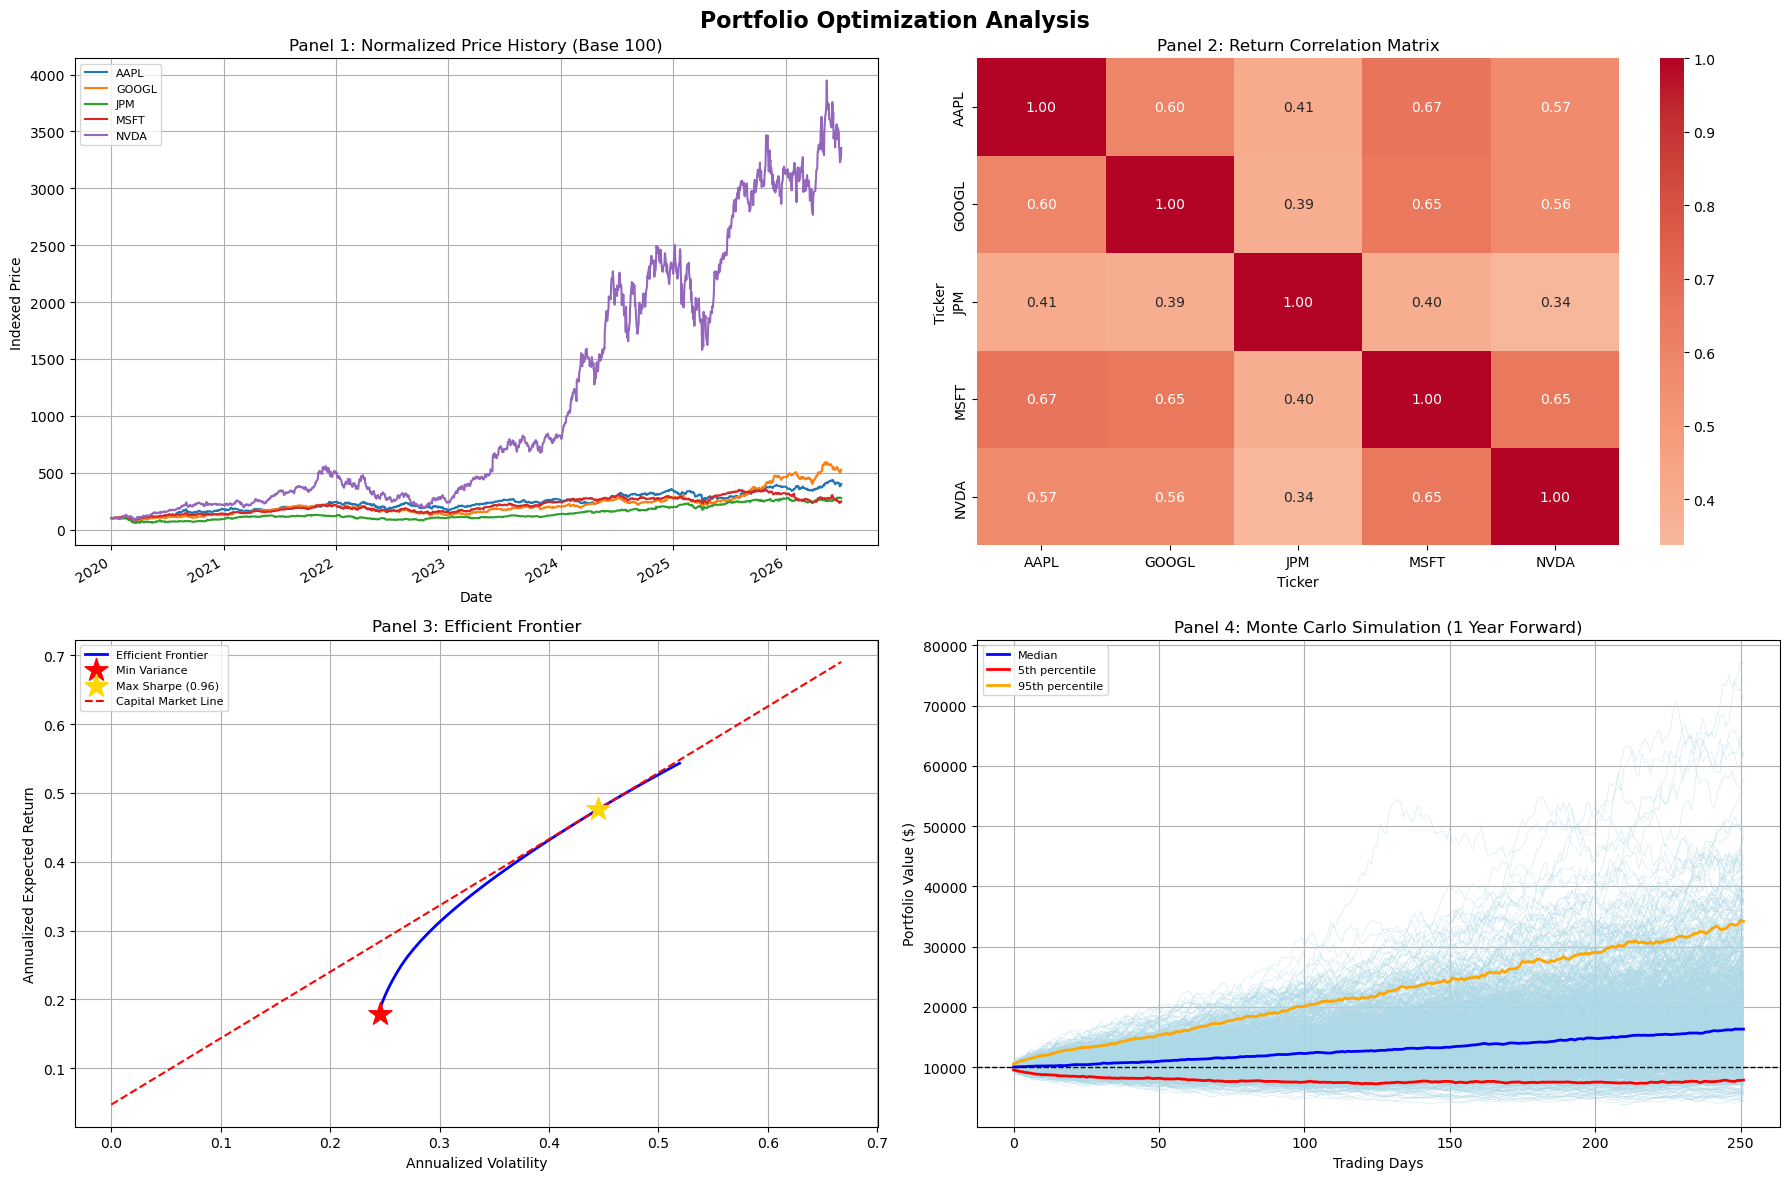

Chart saved as portfolio_analysis_summary.png


In [6]:
frontier_returns,frontier_vols = pe.efficient_frontier(mean_returns,cov_matrix)

pe.plot_analysis(TICKERS, prices,log_returns,mean_returns,cov_matrix,min_weights,max_weights,frontier_returns,frontier_vols,simulation_results,
                var_hist,cvar_hist,historical_portfolio_returns,RISK_FREE_RATE,INITIAL_VALUE)